# Import Libaries

In [45]:
import numpy as np
import pandas as pd

# Importing Data

In [46]:
crop = pd.read_csv("Crop_recommendation.csv")
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# ask Question

In [47]:
crop.shape

(2200, 8)

In [48]:
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [49]:
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [50]:
crop.duplicated().sum()

np.int64(0)

In [51]:
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [52]:
crop['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

# Encoding

In [53]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22
}
crop['crop_num']=  crop['label'].map(crop_dict)

In [54]:
crop

,N,P,K,temperature,humidity,ph,rainfall,label,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1
...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,22
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,22
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,22
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,22


In [55]:
crop.drop(['label'],axis=1,inplace=True)
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


# Train Test Split

In [56]:
X = crop.drop(['crop_num'],axis=1)
y = crop['crop_num']

In [57]:
X

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [58]:
y

0        1
1        1
2        1
3        1
4        1
        ..
2195    22
2196    22
2197    22
2198    22
2199    22
Name: crop_num, Length: 2200, dtype: int64

In [59]:
y.shape

(2200,)

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
X_train

,N,P,K,temperature,humidity,ph,rainfall
1656,17,16,14,16.396243,92.181519,6.625539,102.944161
752,37,79,19,27.543848,69.347863,7.143943,69.408782
892,7,73,25,27.521856,63.132153,7.288057,45.208411
1041,101,70,48,25.360592,75.031933,6.012697,116.553145
1179,0,17,30,35.474783,47.972305,6.279134,97.790725
...,...,...,...,...,...,...,...
1638,10,5,5,21.213070,91.353492,7.817846,112.983436
1095,108,94,47,27.359116,84.546250,6.387431,90.812505
1130,11,36,31,27.920633,51.779659,6.475449,100.258567
1294,11,124,204,13.429886,80.066340,6.361141,71.400430



# Scale the features using MinMaxScaler

In [63]:
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()

X_train = ms.fit_transform(X_train)
X_test = ms.transform(X_test)

In [64]:
X_train

array([[0.12142857, 0.07857143, 0.045     , ..., 0.9089898 , 0.48532225,
        0.29685161],
       [0.26428571, 0.52857143, 0.07      , ..., 0.64257946, 0.56594073,
        0.17630752],
       [0.05      , 0.48571429, 0.1       , ..., 0.57005802, 0.58835229,
        0.08931844],
       ...,
       [0.07857143, 0.22142857, 0.13      , ..., 0.43760347, 0.46198144,
        0.28719815],
       [0.07857143, 0.85      , 0.995     , ..., 0.76763665, 0.44420505,
        0.18346657],
       [0.22857143, 0.52142857, 0.085     , ..., 0.56099735, 0.54465022,
        0.11879596]], shape=(1760, 7))

# Training Models

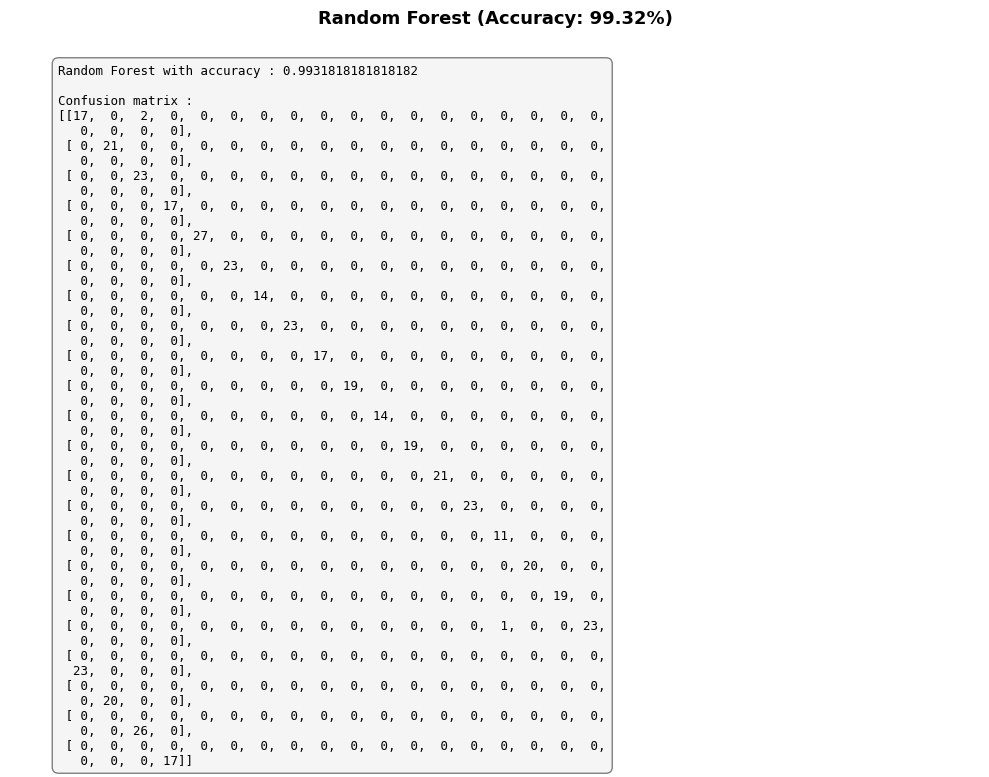

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import numpy as np
import matplotlib.pyplot as plt

# Model
model = RandomForestClassifier(random_state=42)

# Train
model.fit(X_train, y_train)

# Prediction
ypred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, ypred)

# Confusion Matrix
cm = confusion_matrix(y_test, ypred)

# Text display
text = f"Random Forest with accuracy : {acc}\n\nConfusion matrix :\n{np.array2string(cm, separator=', ')}"

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.axis('off')

ax.text(
    0.05,
    0.95,
    text,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
    fontfamily='monospace',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='#F5F5F5',
        edgecolor='gray'
    )
)

ax.set_title(
    f'Random Forest (Accuracy: {acc*100:.2f}%)',
    fontsize=13,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

plt.savefig(
    'figure_random_forest.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

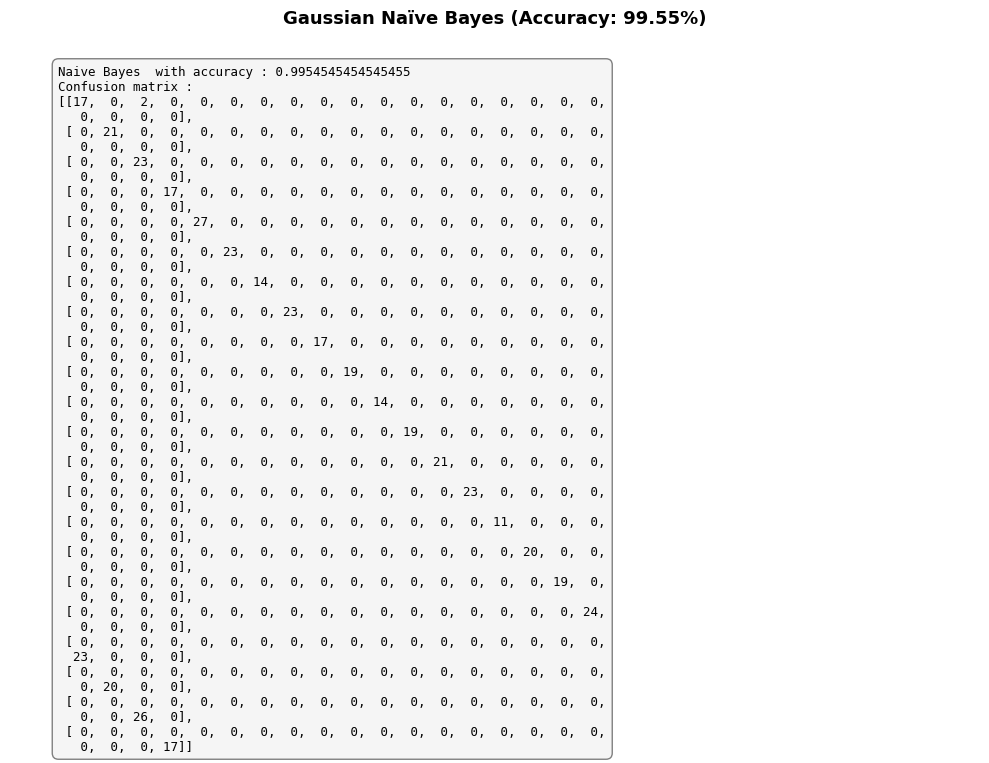

In [66]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)
ypred = model.predict(X_test)
acc = accuracy_score(y_test, ypred)
cm = confusion_matrix(y_test, ypred)

text = f"Naive Bayes  with accuracy : {acc}\nConfusion matrix :\n{np.array2string(cm, separator=', ')}"

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
ax.text(0.05, 0.95, text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='left',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', edgecolor='gray'))
ax.set_title('Gaussian Naïve Bayes (Accuracy: 99.55%)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_gaussian_nb.png', dpi=300, bbox_inches='tight')
plt.show()

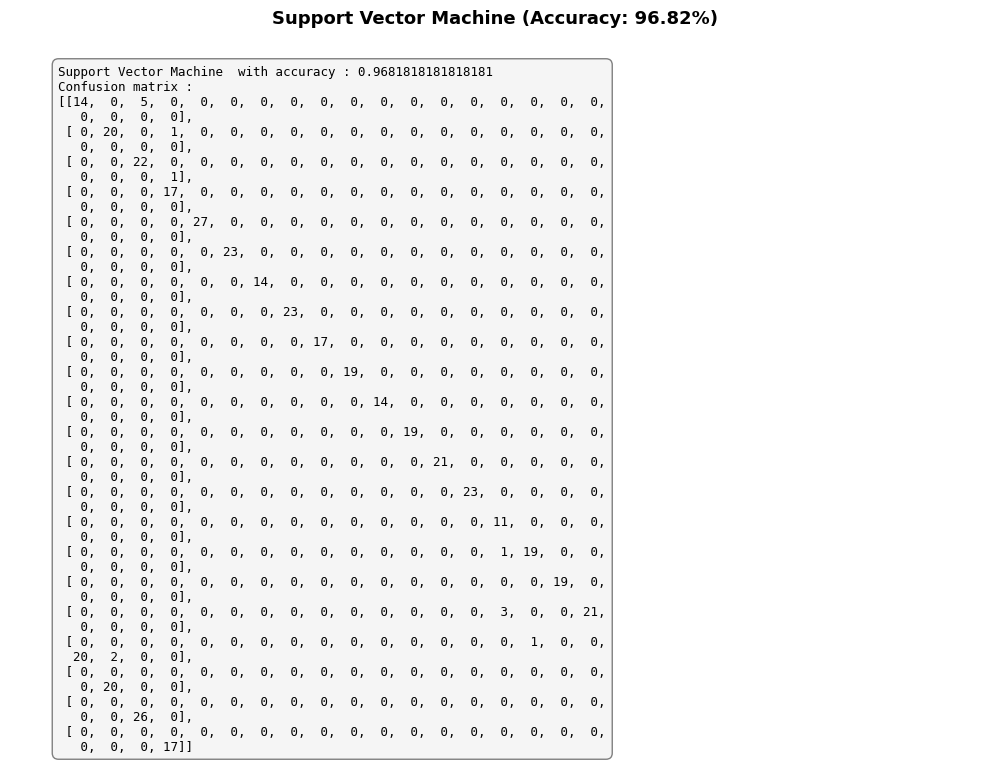

In [67]:
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)
ypred = model.predict(X_test)
acc = accuracy_score(y_test, ypred)
cm = confusion_matrix(y_test, ypred)

text = f"Support Vector Machine  with accuracy : {acc}\nConfusion matrix :\n{np.array2string(cm, separator=', ')}"

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
ax.text(0.05, 0.95, text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='left',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', edgecolor='gray'))
ax.set_title('Support Vector Machine (Accuracy: 96.82%)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_svm.png', dpi=300, bbox_inches='tight')
plt.show()

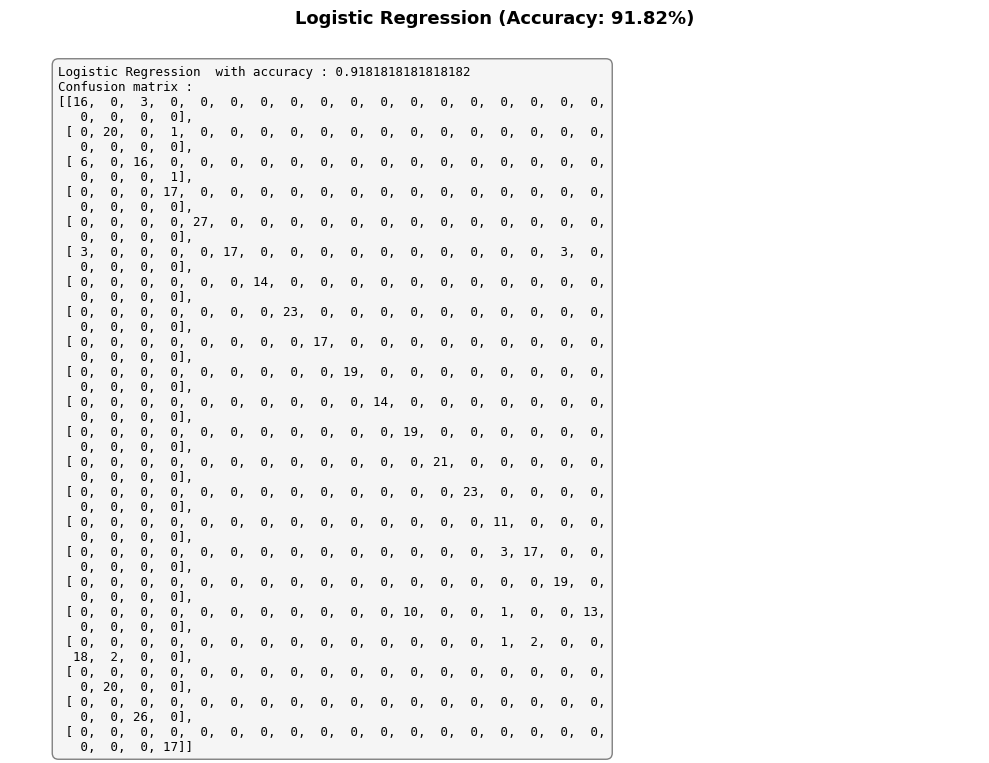

In [68]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
ypred = model.predict(X_test)
acc = accuracy_score(y_test, ypred)
cm = confusion_matrix(y_test, ypred)

# Format output
text = f"Logistic Regression  with accuracy : {acc}\nConfusion matrix :\n{np.array2string(cm, separator=', ')}"

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
ax.text(0.05, 0.95, text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='left',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', edgecolor='gray'))
ax.set_title('Logistic Regression (Accuracy: 91.82%)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_logistic_regression.png', dpi=300, bbox_inches='tight')
plt.show()

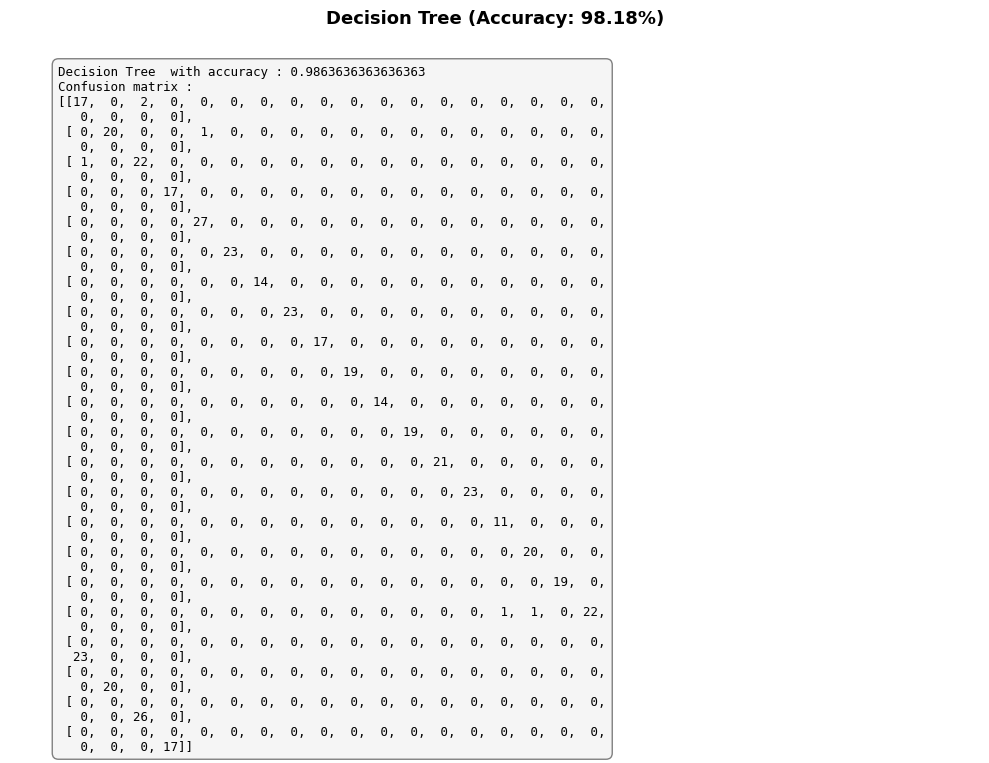

In [69]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
ypred = model.predict(X_test)
acc = accuracy_score(y_test, ypred)
cm = confusion_matrix(y_test, ypred)

text = f"Decision Tree  with accuracy : {acc}\nConfusion matrix :\n{np.array2string(cm, separator=', ')}"

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
ax.text(0.05, 0.95, text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='left',
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F5F5F5', edgecolor='gray'))
ax.set_title('Decision Tree (Accuracy: 98.18%)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('figure_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()


## Confusion Matrices

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Crop Name Mapping

In [71]:
# Mapping from number to crop name (same order as your notebook)
crop_dict = {
    1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut",
    6: "Papaya", 7: "Orange", 8: "Apple", 9: "Muskmelon", 10: "Watermelon",
    11: "Grapes", 12: "Mango", 13: "Banana", 14: "Pomegranate",
    15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
    19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"
}
crop_names = [crop_dict[i] for i in range(1, 23)]

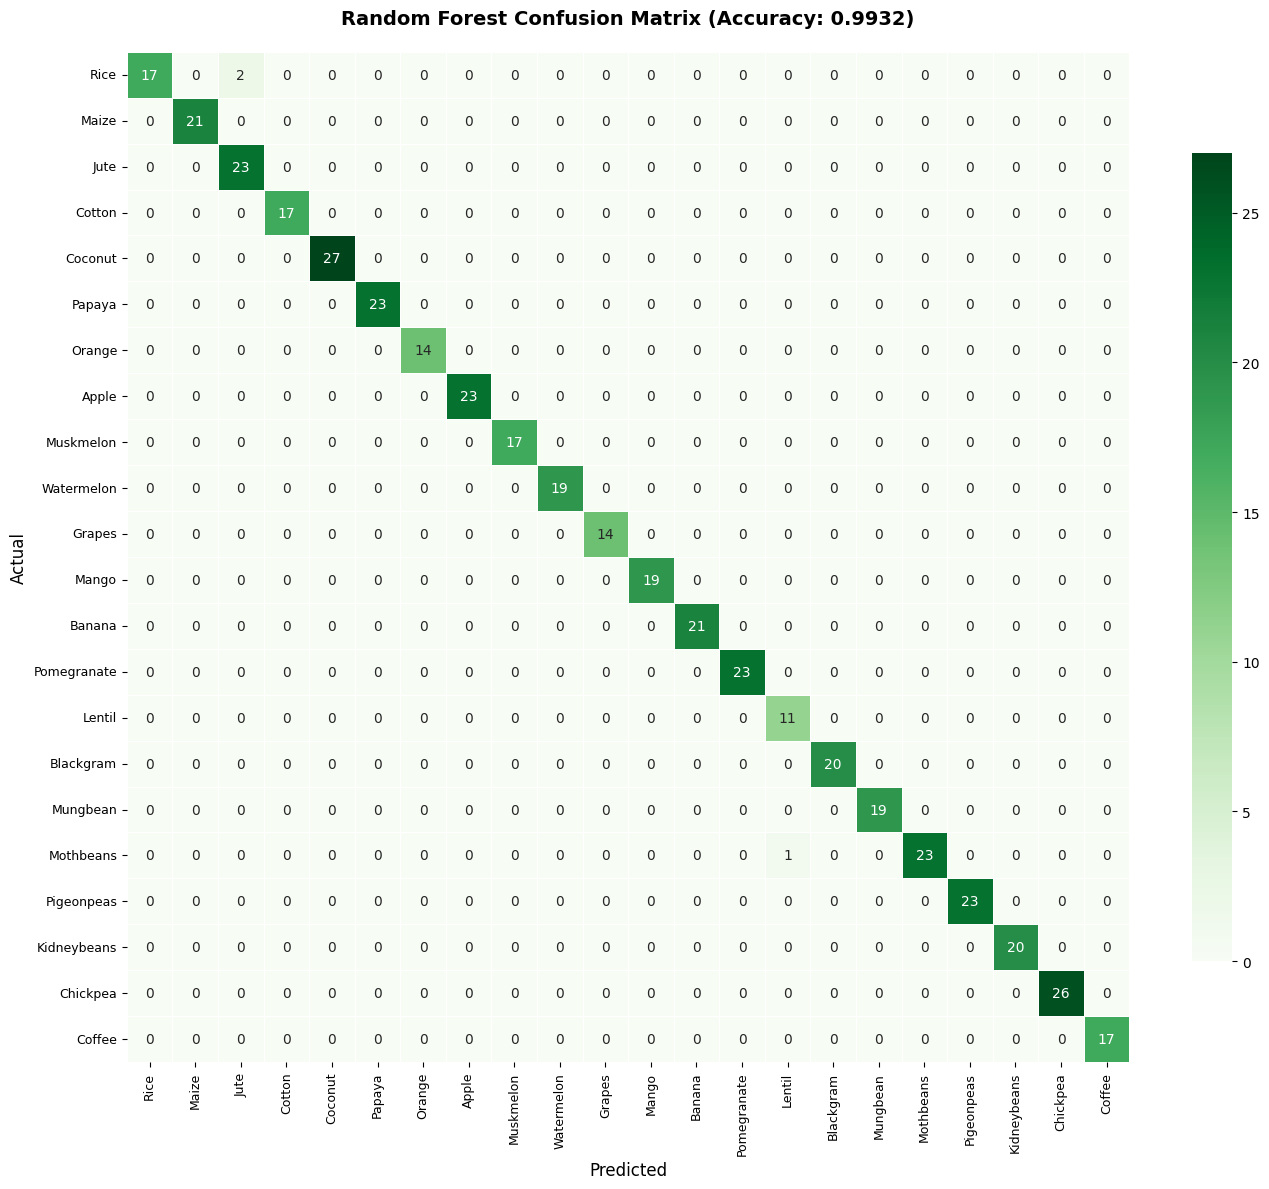

In [72]:
# Train Random Forest (if not already fitted)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
ypred_rf = rf.predict(X_test)
cm_rf = confusion_matrix(y_test, ypred_rf)
acc_rf = accuracy_score(y_test, ypred_rf)

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=crop_names, yticklabels=crop_names,
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
plt.title(f'Random Forest Confusion Matrix (Accuracy: {acc_rf:.4f})',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('figure_7_10_rf_confusion.png', dpi=300, bbox_inches='tight')
plt.show()


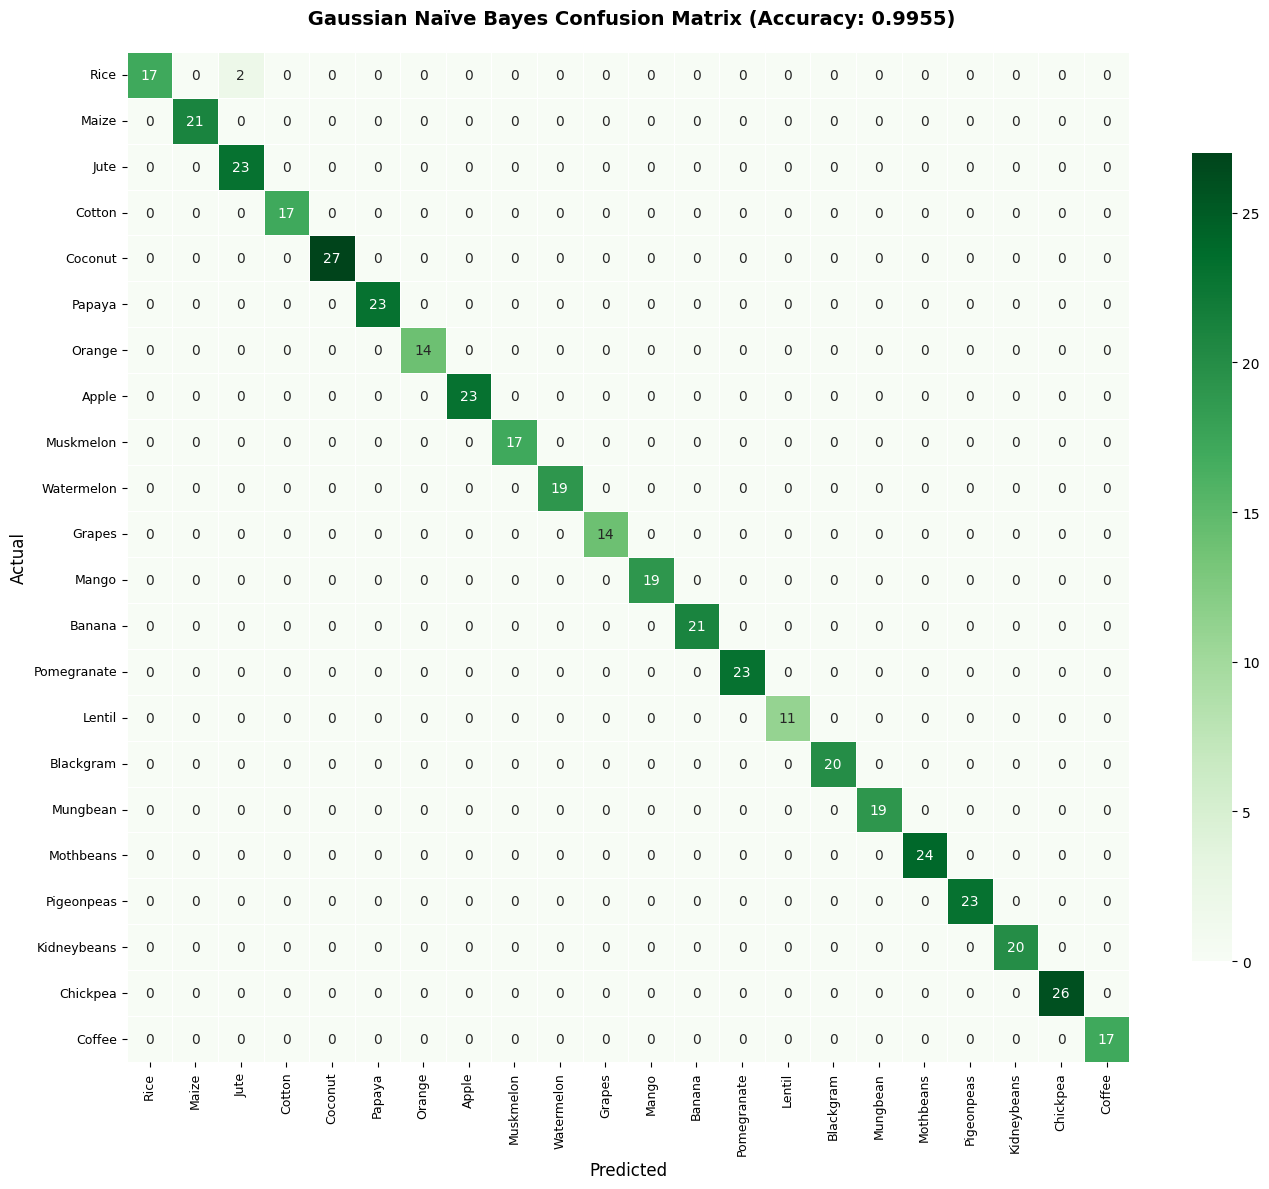

In [73]:
nb = GaussianNB()
nb.fit(X_train, y_train)
ypred_nb = nb.predict(X_test)
cm_nb = confusion_matrix(y_test, ypred_nb)
acc_nb = accuracy_score(y_test, ypred_nb)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=crop_names, yticklabels=crop_names,
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
plt.title(f' Gaussian Naïve Bayes Confusion Matrix (Accuracy: {acc_nb:.4f})',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('figure_7_11_nb_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

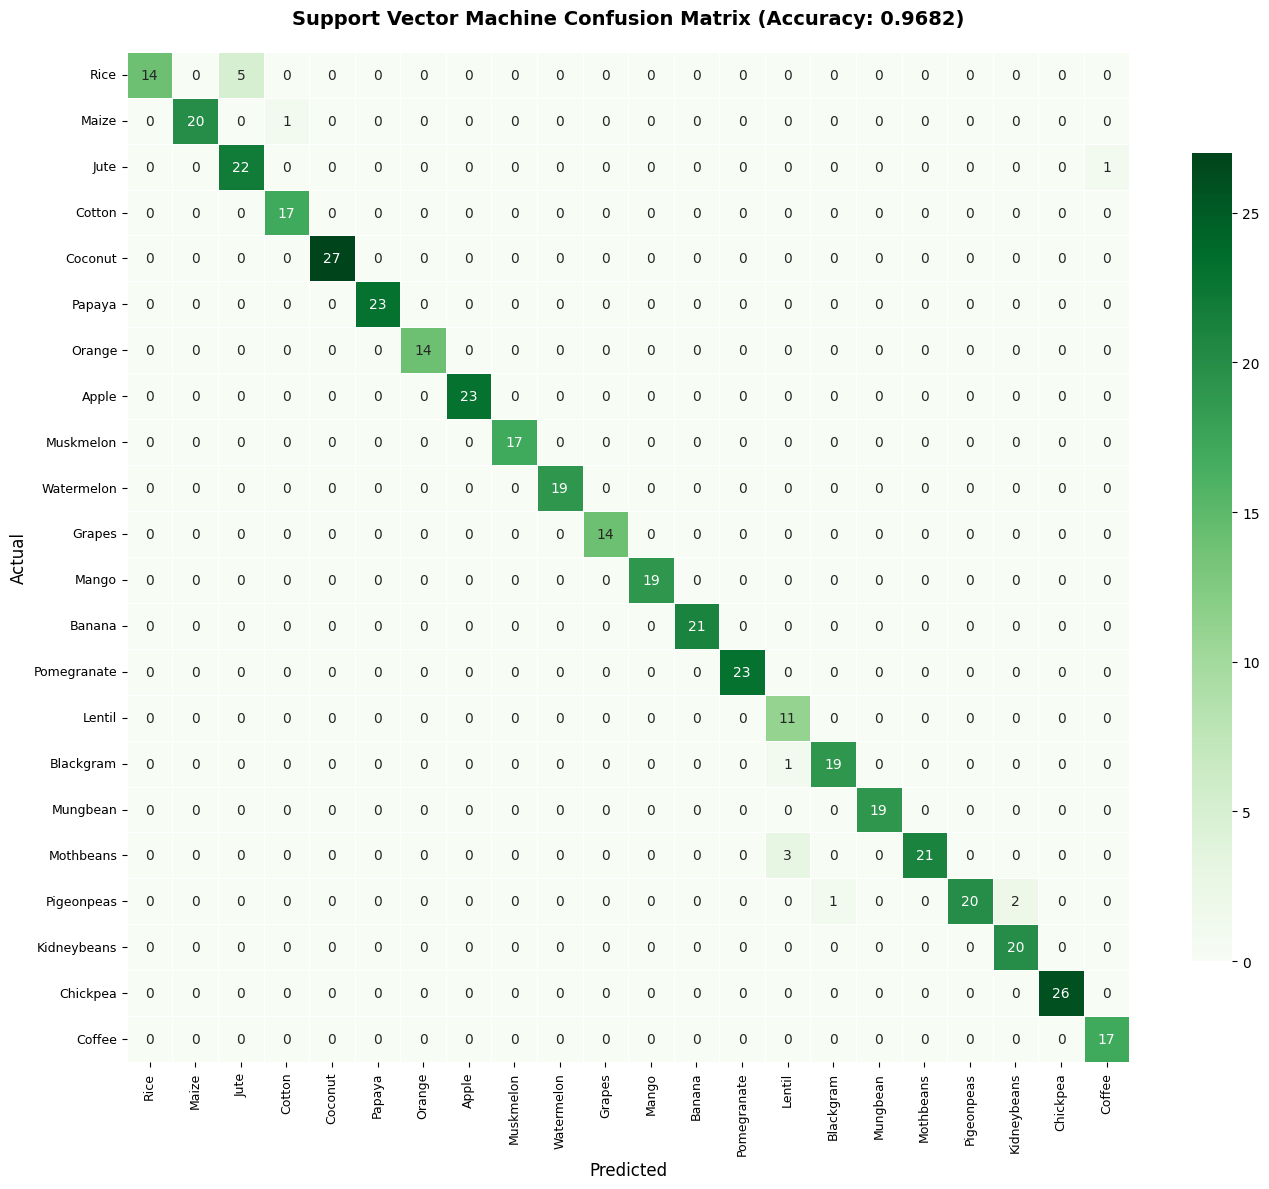

In [74]:
svm = SVC()
svm.fit(X_train, y_train)
ypred_svm = svm.predict(X_test)
cm_svm = confusion_matrix(y_test, ypred_svm)
acc_svm = accuracy_score(y_test, ypred_svm)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=crop_names, yticklabels=crop_names,
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
plt.title(f'Support Vector Machine Confusion Matrix (Accuracy: {acc_svm:.4f})',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('figure_7_12_svm_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

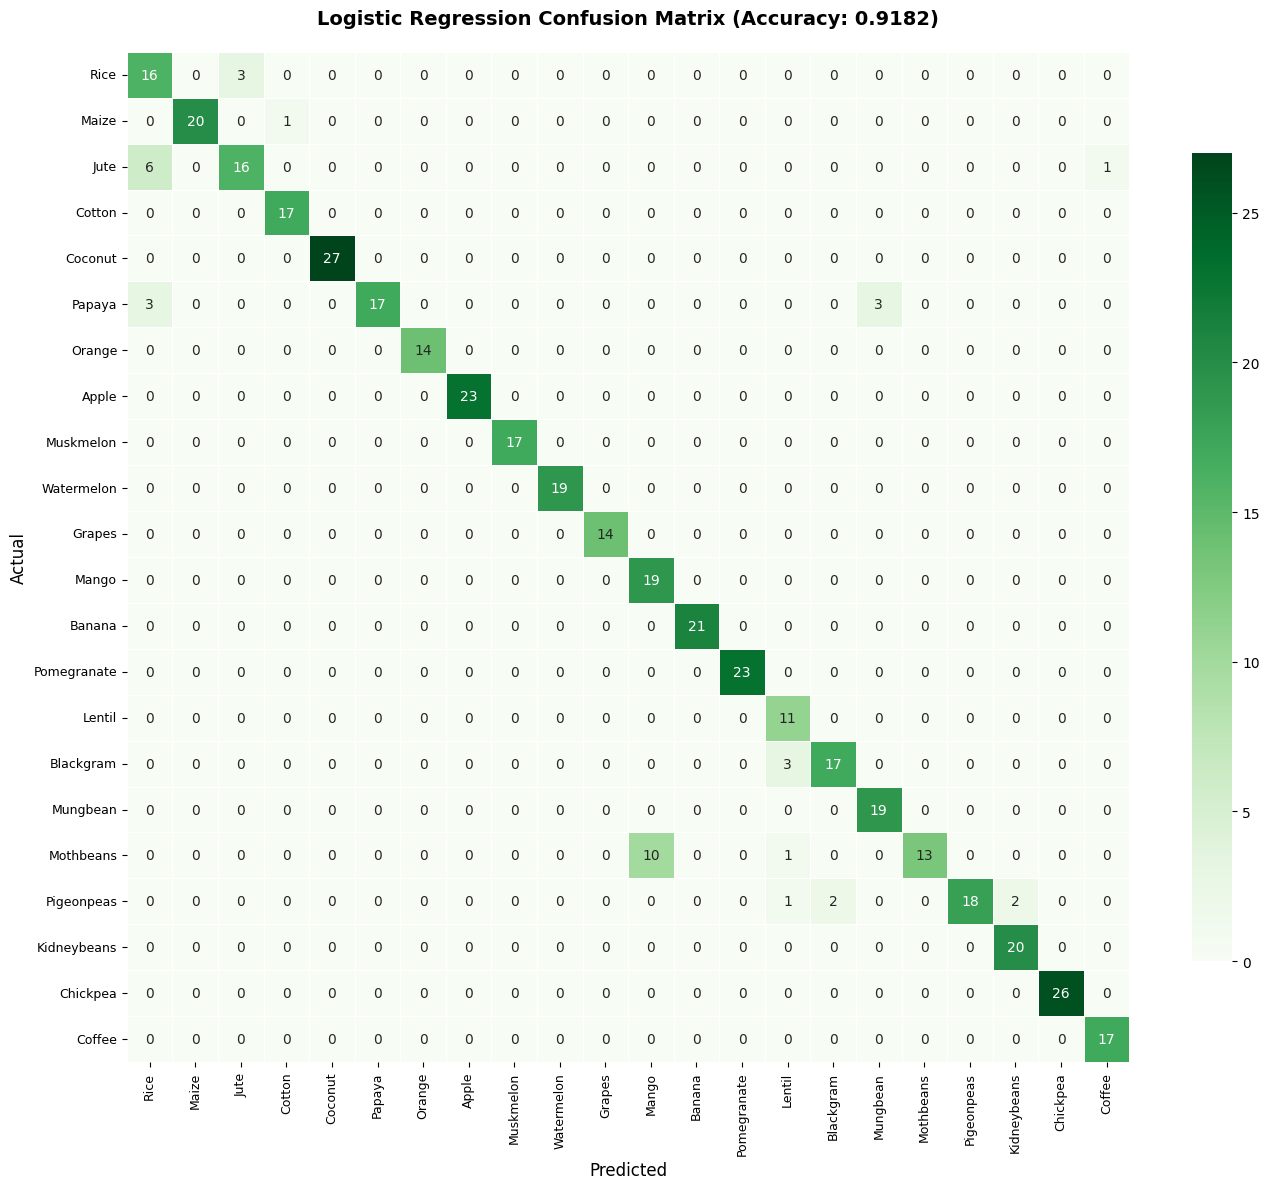

In [75]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
ypred_lr = lr.predict(X_test)
cm_lr = confusion_matrix(y_test, ypred_lr)
acc_lr = accuracy_score(y_test, ypred_lr)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=crop_names, yticklabels=crop_names,
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
plt.title(f'Logistic Regression Confusion Matrix (Accuracy: {acc_lr:.4f})',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('figure_7_13_lr_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

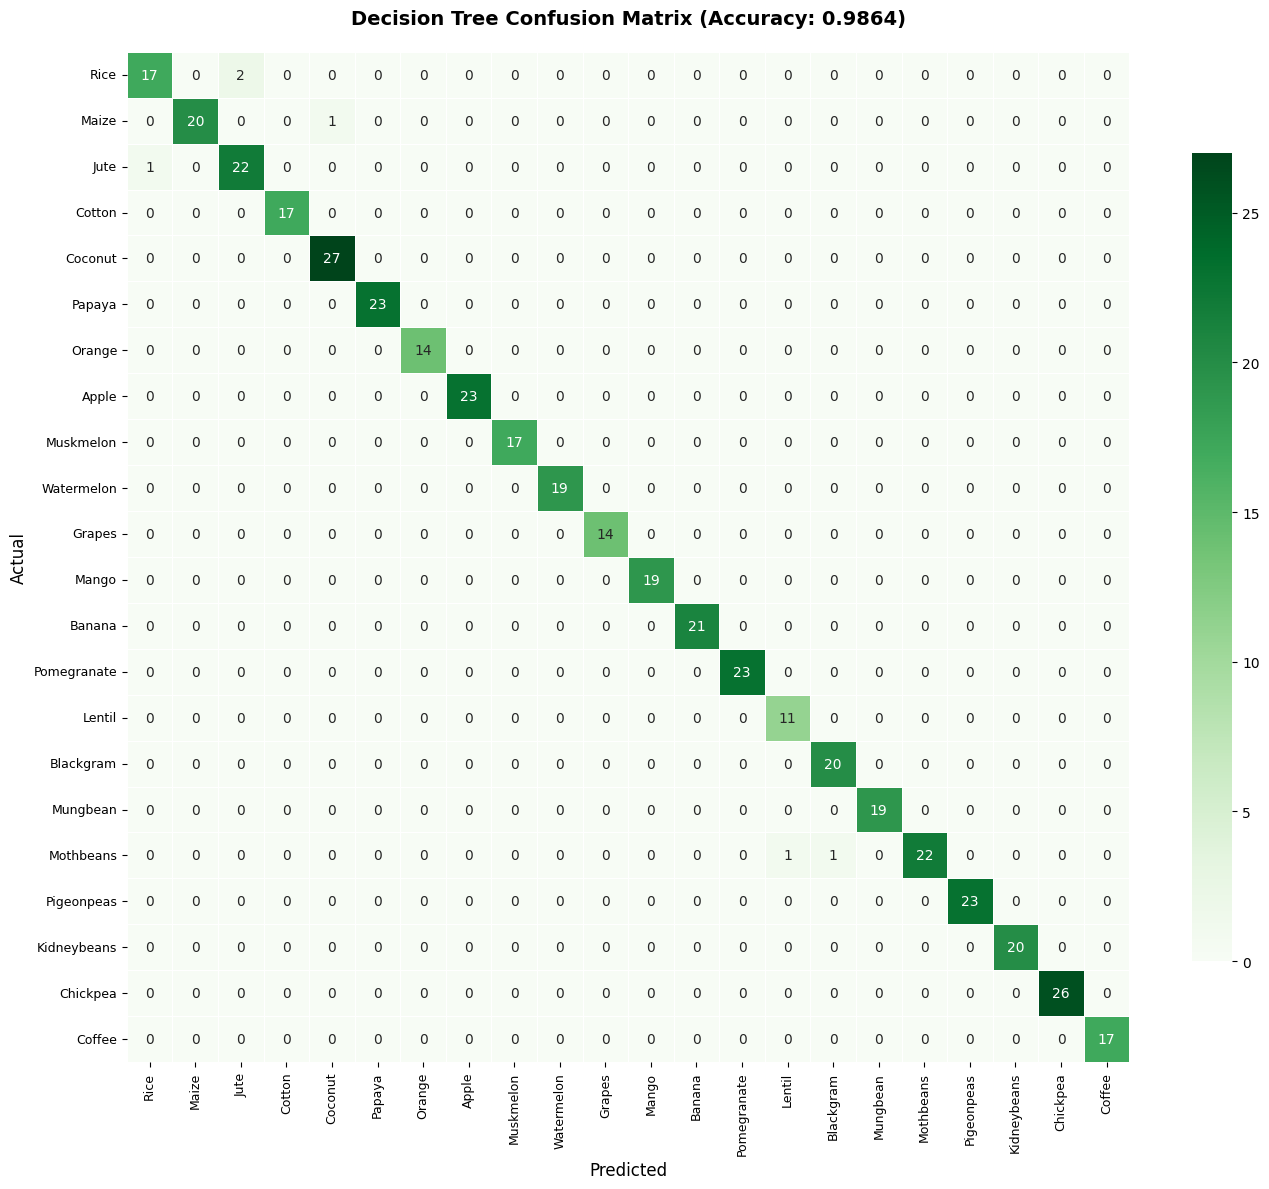

In [76]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
ypred_dt = dt.predict(X_test)
cm_dt = confusion_matrix(y_test, ypred_dt)
acc_dt = accuracy_score(y_test, ypred_dt)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=crop_names, yticklabels=crop_names,
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
plt.title(f'Decision Tree Confusion Matrix (Accuracy: {acc_dt:.4f})',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('figure_7_14_dt_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

## Performance Comparison

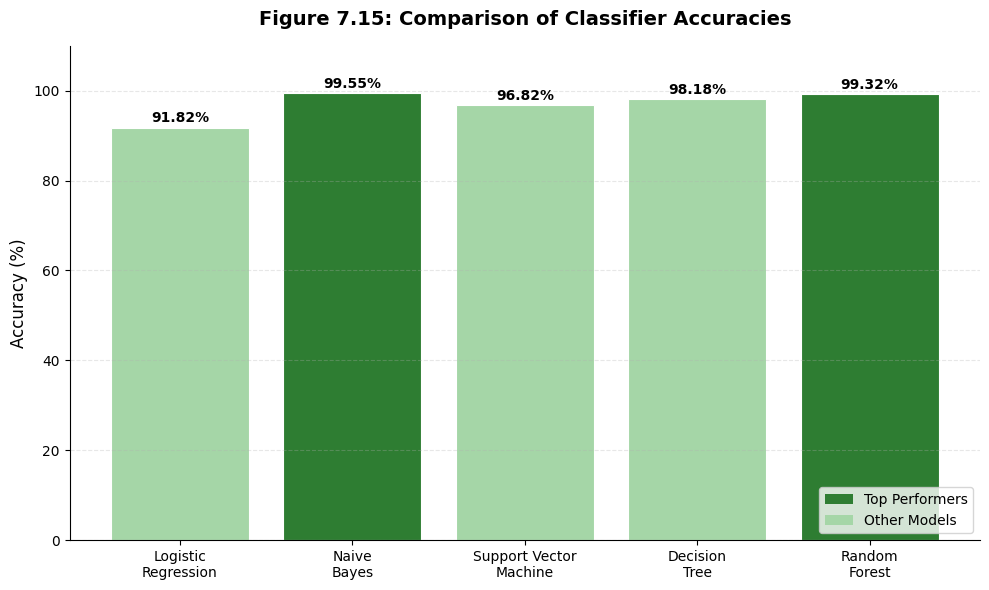

In [ ]:
import matplotlib.pyplot as plt

# Model names and their accuracies (from your notebook)
models = [
    'Logistic\nRegression',
    'Naive\nBayes',
    'Support Vector\nMachine',
    'Decision\nTree',
    'Random\nForest'
]

accuracies = [
    0.9181818181818182,
    0.9954545454545455,
    0.9681818181818181,
    0.9818181818181818,
    0.9931818181818182
]

# Convert to percentages
accuracies_pct = [a * 100 for a in accuracies]

# Highlight top performers (Naive Bayes and Random Forest) in a darker green
colors = ['#A5D6A7', '#2E7D32', '#A5D6A7', '#A5D6A7', '#2E7D32']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies_pct, color=colors, edgecolor='white', linewidth=0.8)

# Add percentage labels on top of bars
for bar, acc in zip(bars, accuracies_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Comparison of Classifier Accuracies', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend for top performers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E7D32', label='Top Performers'),
    Patch(facecolor='#A5D6A7', label='Other Models')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('figure_7_15_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

# create instances of all models
models = {
    'Logistic Regression': LogisticRegression(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Bagging': BaggingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Extra Trees': ExtraTreeClassifier(),
}


for name, model in models.items():
    model.fit(X_train,y_train)
    ypred = model.predict(X_test)

    print(f"{name}  with accuracy : {accuracy_score(y_test,ypred)}")
    print("Confusion matrix : ",confusion_matrix(y_test,ypred))
    print("==========================================================")


Logistic Regression  with accuracy : 0.9181818181818182
Confusion matrix :  [[16  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 20  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 6  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 3  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  3  0  0  0  0  0]
 [ 0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  

In [79]:
# finally selected randomforest model

rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
ypred = rfc.predict(X_test)
accuracy_score(y_test,ypred)

0.9931818181818182

# Predictive System

In [80]:
def recommendation(N,P,k,temperature,humidity,ph,rainfal):
    features = np.array([[N,P,k,temperature,humidity,ph,rainfal]])
    transformed_features = ms.fit_transform(features)
    prediction = rfc.predict(transformed_features)
    print(prediction)
    return prediction[0]

In [81]:
# new inputs


N = 40
P = 50
k = 50
temperature = 40.0
humidity = 20
ph = 100
rainfall = 100

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[9]
Muskmelon is a best crop to be cultivated 


In [82]:
# new inputs 2


N = 100
P = 90
k = 100
temperature = 50.0
humidity = 90.0
ph = 100
rainfall = 202.0

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[9]
Muskmelon is a best crop to be cultivated 


In [83]:
# new inputs 2
N = 10
P = 10
k = 10
temperature = 15.0
humidity = 80.0
ph = 4.5
rainfall = 10.0

predict = recommendation(N,P,k,temperature,humidity,ph,rainfall)

crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}

if predict in crop_dict:
    crop = crop_dict[predict]
    print("{} is a best crop to be cultivated ".format(crop))
else:
    print("Sorry are not able to recommend a proper crop for this environment")

[9]
Muskmelon is a best crop to be cultivated 


In [84]:
import pickle
pickle.dump(rfc,open('model.pkl','wb'))
pickle.dump(ms,open('minmaxscaler.pkl','wb'))

/tmp/ipykernel_7291/1949277027.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_counts.index, rotation=90, fontsize=9)


NameError: name 'splt' is not defined

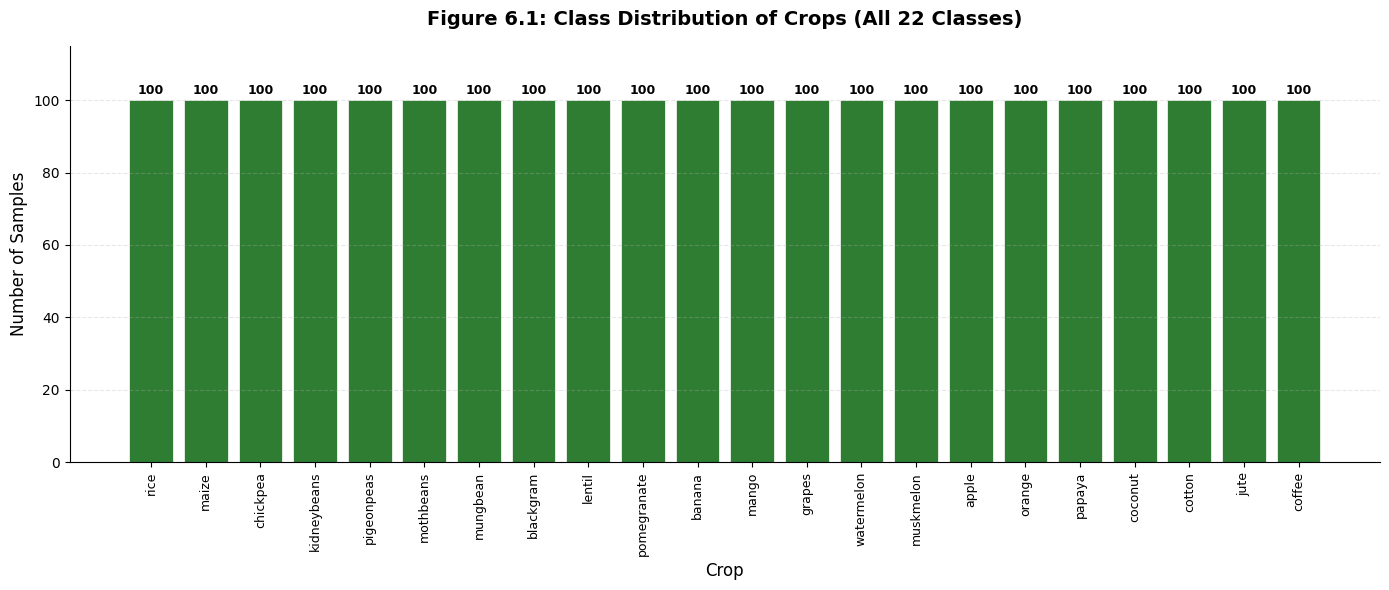

In [85]:







import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load data (or use existing 'crop' DataFrame)
crop = pd.read_csv("Crop_recommendation.csv")

# Get class counts (all 100)
class_counts = crop['label'].value_counts()

# Create figure
fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(class_counts.index, class_counts.values, color='#2E7D32', edgecolor='white', linewidth=0.5)

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Styling
ax.set_title('Figure 6.1: Class Distribution of Crops (All 22 Classes)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Crop', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_ylim(0, 115)
ax.set_xticklabels(class_counts.index, rotation=90, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure_6_1_class_distribution.png', dpi=300, bbox_inches='tight')
splt.show()

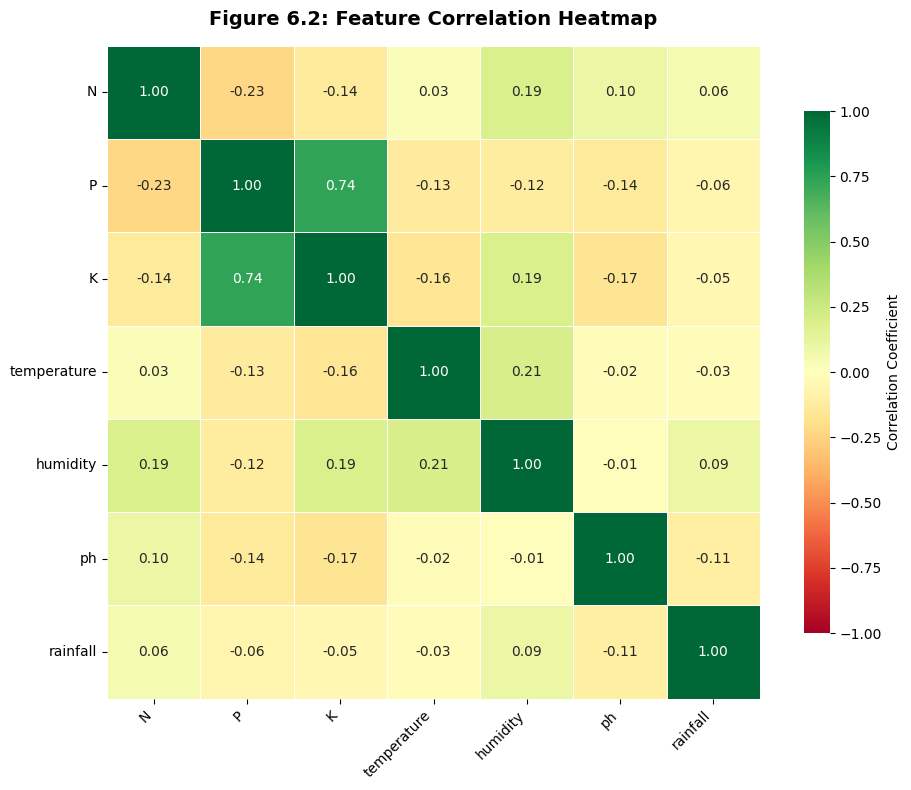

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numeric feature columns (exclude label and crop_num)
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
corr_matrix = crop[features].corr()

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap with annotations
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask upper triangle for cleaner look
# Set mask=None if you want full matrix
heatmap = sns.heatmap(corr_matrix,
                      annot=True,
                      fmt='.2f',
                      cmap='RdYlGn',
                      center=0,
                      vmin=-1,
                      vmax=1,
                      square=True,
                      linewidths=0.5,
                      linecolor='white',
                      cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
                      ax=ax)

ax.set_title('Figure 6.2: Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('figure_6_2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Importance from Random Forest

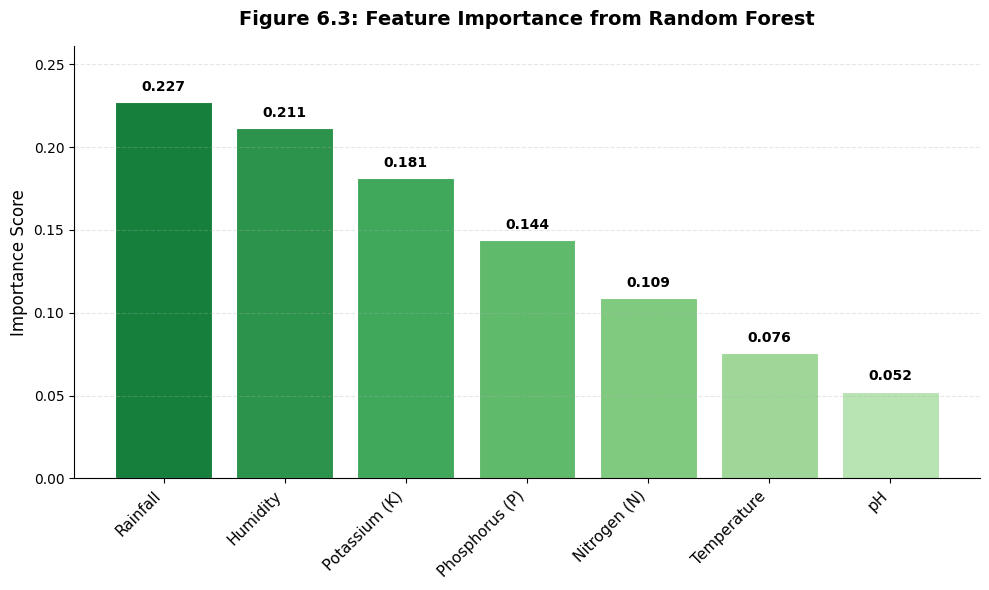

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest to get feature importances
rfc_importance = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_importance.fit(X_train, y_train)

# Get feature names and importance scores
feature_names = ['Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)',
                 'Temperature', 'Humidity', 'pH', 'Rainfall']
importances = rfc_importance.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1]
sorted_names = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Color palette: gradient from dark green (most important) to light green
colors = plt.cm.Greens(np.linspace(0.8, 0.3, len(sorted_importances)))

bars = ax.bar(range(len(sorted_importances)), sorted_importances, color=colors, edgecolor='white', linewidth=0.8)

# Add value labels
for i, (bar, imp) in enumerate(zip(bars, sorted_importances)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{imp:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(range(len(sorted_importances)))
ax.set_xticklabels(sorted_names, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Importance Score', fontsize=12)
ax.set_title('Figure 6.3: Feature Importance from Random Forest', fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(sorted_importances) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure_6_3_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

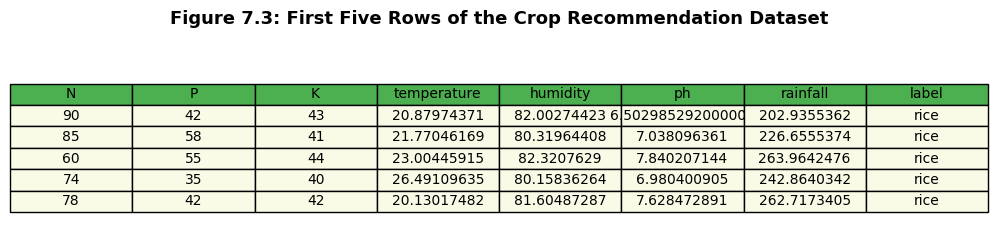

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the original data (to show label column)
crop = pd.read_csv("Crop_recommendation.csv")

# Take the first 5 rows
head_df = crop.head()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

# Create the table
table = ax.table(
    cellText=head_df.values,
    colLabels=head_df.columns,
    cellLoc='center',
    loc='center',
    colColours=['#4CAF50'] * len(head_df.columns),  # green header
    cellColours=[['#f9fbe7'] * len(head_df.columns) for _ in range(len(head_df))]
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Title
ax.set_title('Figure 7.3: First Five Rows of the Crop Recommendation Dataset',
             fontsize=13, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('figure_7_3_dataset_head.png', dpi=300, bbox_inches='tight')
plt.show()

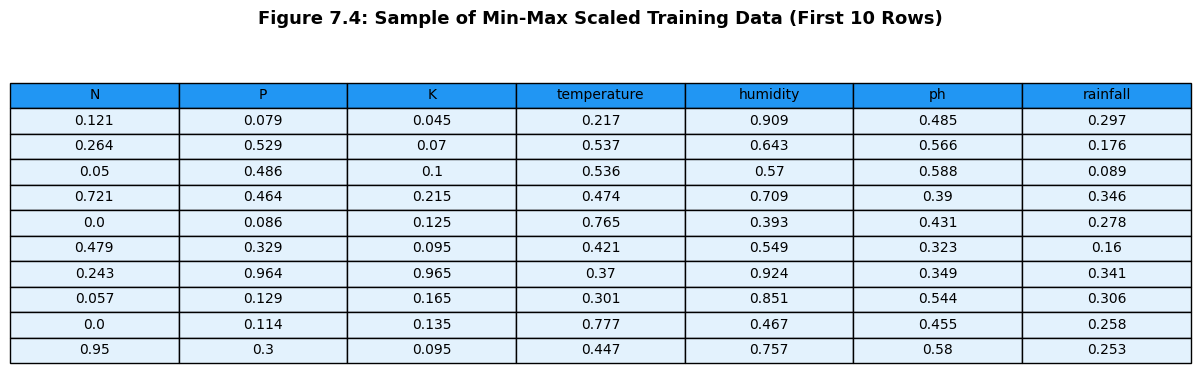

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Re-run scaling (or use your existing X_train_scaled)
crop = pd.read_csv("Crop_recommendation.csv")
crop_dict = {'rice':1, 'maize':2, 'jute':3, 'cotton':4, 'coconut':5, 'papaya':6,
             'orange':7, 'apple':8, 'muskmelon':9, 'watermelon':10, 'grapes':11,
             'mango':12, 'banana':13, 'pomegranate':14, 'lentil':15, 'blackgram':16,
             'mungbean':17, 'mothbeans':18, 'pigeonpeas':19, 'kidneybeans':20,
             'chickpea':21, 'coffee':22}
crop['crop_num'] = crop['label'].map(crop_dict)
crop.drop('label', axis=1, inplace=True)

X = crop.drop('crop_num', axis=1)
y = crop['crop_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ms = MinMaxScaler()
X_train_scaled = ms.fit_transform(X_train)

# Take first 10 rows for display
sample = X_train_scaled[:10]
feature_names = X.columns

# Round values to 3 decimal places
sample_rounded = np.round(sample, 3)

# Create figure
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# Create table
table = ax.table(
    cellText=sample_rounded,
    colLabels=feature_names,
    cellLoc='center',
    loc='center',
    colColours=['#2196F3'] * len(feature_names),
    cellColours=[['#e3f2fd'] * len(feature_names) for _ in range(len(sample_rounded))]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

ax.set_title('Figure 7.4: Sample of Min‑Max Scaled Training Data (First 10 Rows)',
             fontsize=13, fontweight='bold', pad=30)

plt.tight_layout()
plt.savefig('figure_7_4_scaled_data.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
table